<a href="https://colab.research.google.com/github/DDanso98/IntroToAI/blob/main/Assignment_6_DDanso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 6: House Price Prediction Using California Housing Data | Dominic Danso - September 13, 2026**

In [1]:
#Import Relevant Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## **Assignment Simple machine Learning Project cycle**

### **_House Price Prediction Using California Housing Data_**
This dataset provides information about house prices in California. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "California Housing Dataset" from sklearn.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (California Housing):
* MedInc: Median income in block group
* HouseAge: Median house age in block group
* AveRooms: Average number of rooms per household
* AveBedrms: Average number of bedrooms per household
* Population: Block group population
* AveOccup: Average number of household members
* Latitude: Block group latitude
* Longitude: Block group longitude
* MedHouseVal (Target): Median house value in block group




**Task 2: Data Collection and Loading**

In [ ]:
# TODO: Load the 'California Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Hint: Use `fetch_california_housing()` from `sklearn.datasets`

In [7]:
#Load the 'California Housing' dataset from sklearn
housing = fetch_california_housing(as_frame=True)

#Convert the dataset to a pandas DataFrame
df = pd.DataFrame(data=housing.data, columns=housing.feature_names)

#Add the target variable to the DataFrame
df['MedHouseVal'] = housing.target

**Task 3: Quick Check of Data**

In [ ]:
# TODO: Display the first few rows of the dataset to understand its structure.
# Hint: Use `.head()` to inspect the first few rows.

In [8]:
#Inspect Housing Data
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Hint: Use `.info()` and `.describe()` to inspect data types and statistical properties.

In [9]:
#Inspect 'df' Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [10]:
#Inspect 'df' Statistical Properties
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


**Task 4: EDA and Data Preprocessing**

In [ ]:
# TODO: Check for missing/null values.
# Hint: Use `.isnull().sum()` to check for null values.

In [11]:
#Identify Missing Values
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [ ]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable (MedHouseVal).
# Example: Use `plt.scatter()` to visualize the relationship between 'MedInc' and 'MedHouseVal'.

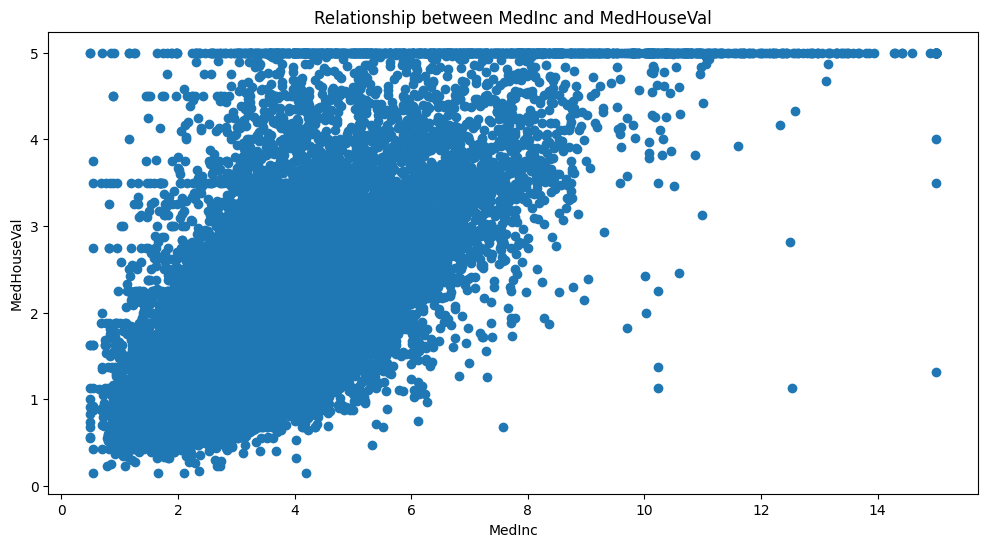

In [13]:
#Visualize Relationship Between 'MedInc' & 'MedHouseVal'
plt.figure(figsize=(12, 6))
plt.scatter(df['MedInc'], df['MedHouseVal'])
plt.xlabel('MedInc')
plt.ylabel('MedHouseVal')
plt.title('Relationship between MedInc and MedHouseVal')
plt.show()

In [ ]:
# TODO: Create a function to automate scatter plots for all features vs MedHouseVal.

In [17]:
#Define Function To Create Remaining Scatter Plots
def scatter_plots(features):
    for feature in features:
        plt.figure(figsize=(10, 8))
        plt.scatter(df[feature], df['MedHouseVal'])
        plt.xlabel(feature)
        plt.ylabel('MedHouseVal')
        plt.title(f'Relationship between {feature} and MedHouseVal')
        plt.show()
        plt.close()

In [ ]:
# TODO: Use the function to visualize the relationships between multiple features and the target variable.
# Features: ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
# Target: 'MedHouseVal'

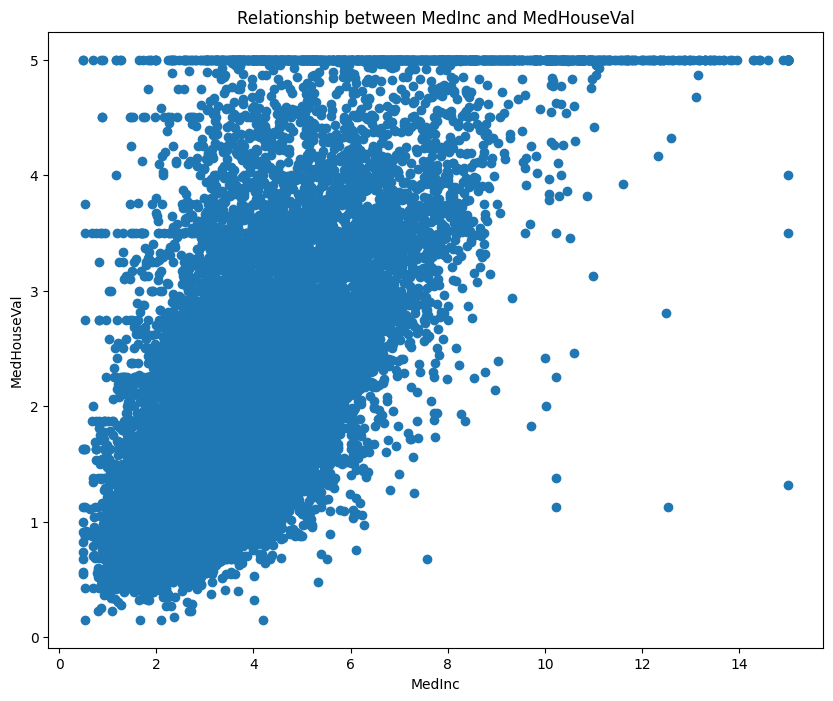

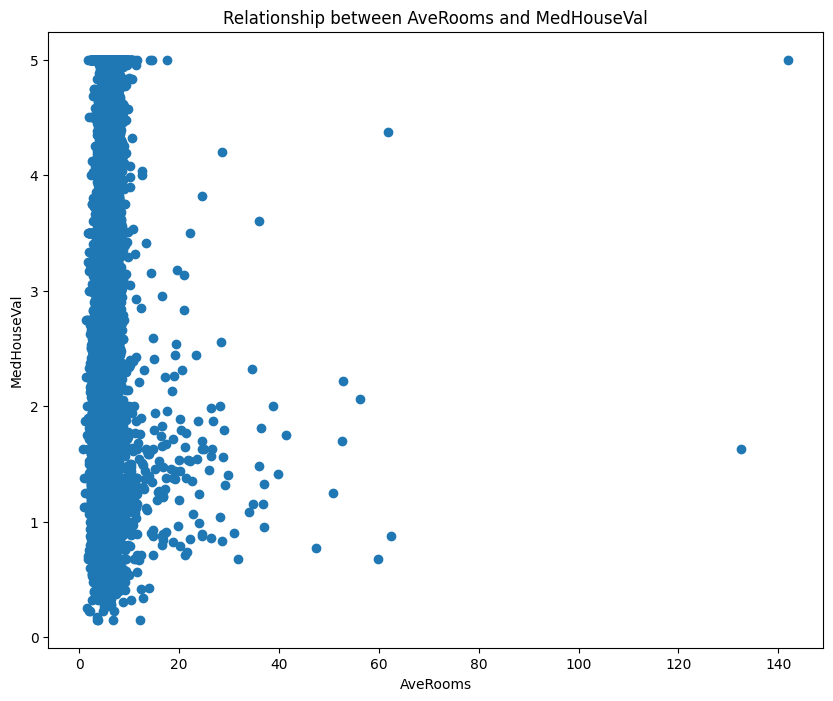

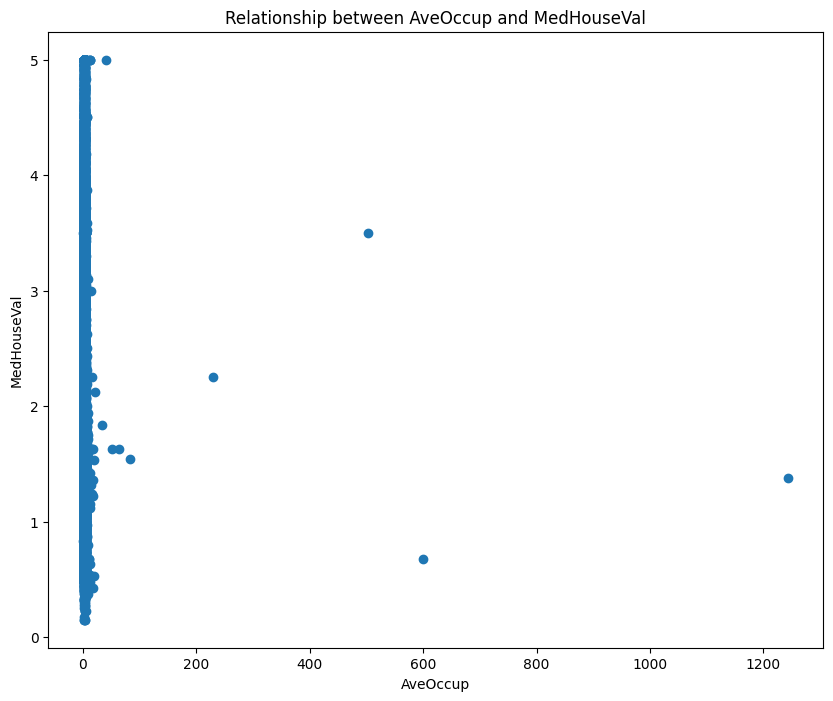

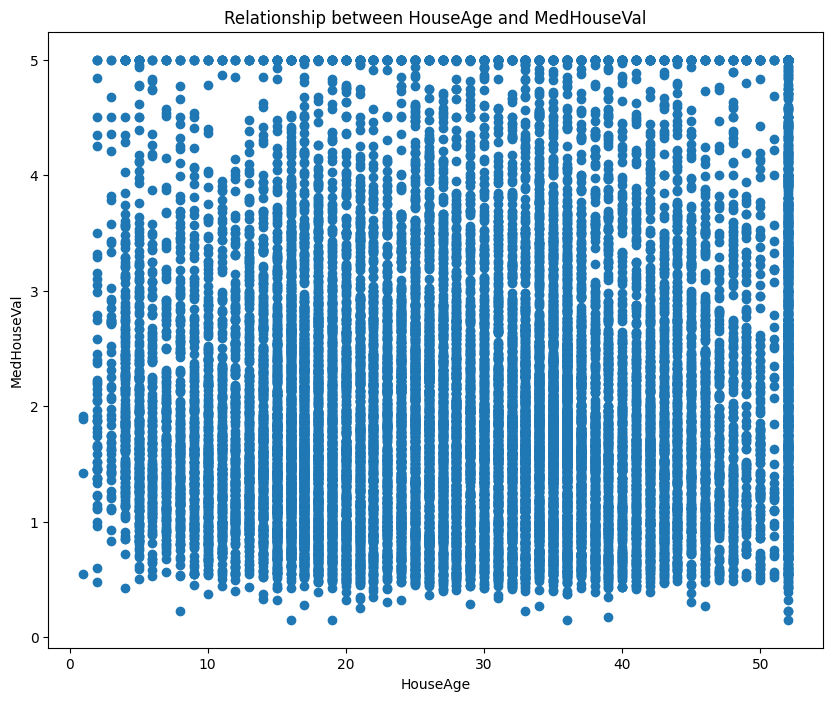

In [18]:
#Visualize Relationship between Multiple Features & Target
features = ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
scatter_plots(features)

**Task 5: ML Model Training**

In [ ]:
# TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.

# Define X (features) and y (target) and perform the train-test split:

In [29]:
#Split Data Into Train/Test Sets
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# TODO: Choose an appropriate regression model.
# Hint: Use `LinearRegression()` from `sklearn.linear_model`.

# Define your regression model here:

In [30]:
#Choose ML Model
model = LinearRegression()

In [ ]:
# TODO: Train the model on the training data.
# Hint: Use `.fit()` to train the model.

In [31]:
#Train Linear Regression Model
model.fit(X_train, y_train)

print(model.score(X_train, y_train))

0.6125511913966952


**Task 6: Model Evaluation**

In [ ]:
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.

In [32]:
#Model Evaluation Using Mean Squared Error
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 0.5558915986952444


In [33]:
#Model Evaluation Using R-Squared
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2}")

R-squared: 0.5757877060324508


**Task 7: Model Prediction**

In [ ]:
# TODO: Predict Median House Value from a new set of feature inputs.
# Example new data: 'MedInc' = 3, 'HouseAge' = 30, 'AveRooms' = 6, 'AveOccup' = 3, 'Latitude' = 34, 'Longitude' = -118, 'AveBedrms' = 1, 'Population' = 1500
# Hint: Use `.predict()` on a new data array.

In [34]:
#Test Model Prediction Using New Data
predict_data = pd.DataFrame([{
    'MedInc': 3,
    'HouseAge': 30,
    'AveRooms': 6,
    'AveBedrms': 1,
    'Population': 1500,
    'AveOccup': 3,
    'Latitude': 34,
    'Longitude': -118
}])

prediction = model.predict(predict_data)
print("Predicted Median House Value:", prediction)

Predicted Median House Value: [1.54866333]


The linear regression model achieved an R² of 0.576 and an MSE of 0.556, indicating that approximately 58% of the variance in median house values is explained by the selected features. While this suggests the model captures a meaningful portion of the underlying relationship, a substantial share of variance remains unexplained.

Colab Notebook: https://colab.research.google.com/drive/1g8kLBM-4hZMQ8_h9r43vX-3IIW1PmE-Q?usp=sharing